# Generate Random Points

This example demonstrates how to generate random sample points with TAT-C, either uniformly distributed over the Earth's surface or weighted by a gridded dataset such as population, and how to identify when a simple imaging satellite observes them. Random points complement the regular point distributions (for example, `generate_points_fibonacci_lattice`) when an analysis should sample locations in proportion to where they matter, such as where people live.

## Uniform Random Points

The `generate_points_random` function generates a number of random points. Without weights, points are distributed uniformly by surface area: unlike uniform random longitudes and latitudes, they do not cluster near the poles. An optional `mask` (a shapely `Polygon` or `MultiPolygon`) constrains points to a region, and a `seed` makes the results reproducible. Results are formatted as a GeoDataFrame with a `point_id` (the hash of each point's geometry) and a `geometry` column.

In [1]:
from tatc.generation import generate_points_random

uniform_points = generate_points_random(100, seed=0)
display(uniform_points)

,point_id,geometry
0,f3c80e0f1149bff0,POINT Z (-98.68701 -1.65778 0)
1,fcf9476f6d7083d6,POINT Z (-135.16031 -8.9019 0)
2,f15f44495124c8fa,POINT Z (-76.20093 49.03042 0)
3,7063758f19160724,POINT Z (31.0043 -55.72766 0)
4,b1c6ae031fe96035,POINT Z (19.47258 24.63509 0)
...,...,...
95,c4089597e34f07f1,POINT Z (-153.51735 79.75185 0)
96,eab790e6cfb03009,POINT Z (-154.68255 57.93979 0)
97,76ef601832ef21d7,POINT Z (132.78755 -44.1057 0)
98,9f99d2be5eba25e1,POINT Z (48.26519 10.36517 0)


## Population-Weighted Random Points

Points can also be weighted by a raster of non-negative values, such as population counts. A raster cell is chosen with probability proportional to its value, and a point is placed uniformly by area within it. Weights are a two-dimensional array (with rows from north to south and columns from west to east, as in a GeoTIFF) and the bounds (west, south, east, north) of the raster in degrees. If values are per unit area (for example, people per square kilometer), the `density=True` option scales each by its cell's area.

This example uses the [Global Human Settlement Layer (GHSL)](https://human-settlement.emergency.copernicus.eu/ghs_pop2023.php) population grid (GHS-POP R2023A) from the European Commission's Joint Research Centre, which estimates the residential population of each grid cell for the 2020 epoch at a 30 arc-second (about 1 km) resolution in WGS84 (EPSG:4326) coordinates. It is public and requires no authentication, but is distributed as a 480 MB archive.

The `read_raster_weights` function in the `tatc.preprocess` module (installed via `pip install tatc[preprocess]`) reads weights from a GeoTIFF, optionally only within the bounds of a mask. It can also aggregate large rasters to coarser cells: here, blocks of 120 by 120 cells are summed to population counts on a 1-degree grid, which is ample for this example. To keep this notebook quick to re-run, the 1-degree grid is stored in a small GeoTIFF alongside this notebook; set `REGENERATE_POPULATION` to `True` to download the source data and derive it again.

In [2]:
import os
import urllib.request

import rasterio
from rasterio.transform import from_bounds

from tatc.preprocess import read_raster_weights

POPULATION_PATH = "ghs_pop_2020_1deg.tif"
REGENERATE_POPULATION = False  # set True to re-derive from the GHSL source data (480 MB)

if REGENERATE_POPULATION:
    name = "GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0"
    url = (
        "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_POP_GLOBE_R2023A/"
        f"GHS_POP_E2020_GLOBE_R2023A_4326_30ss/V1-0/{name}.zip"
    )
    if not os.path.exists(f"{name}.zip"):
        urllib.request.urlretrieve(url, f"{name}.zip")
    # sum 120 x 120 blocks of 30 arc-second cells to 1-degree population counts
    population, bounds = read_raster_weights(f"/vsizip/{name}.zip/{name}.tif", aggregate=120)
    with rasterio.open(
        POPULATION_PATH,
        "w",
        driver="GTiff",
        height=population.shape[0],
        width=population.shape[1],
        count=1,
        dtype="float32",
        crs="EPSG:4326",
        transform=from_bounds(*bounds, population.shape[1], population.shape[0]),
        compress="deflate",
    ) as dst:
        dst.write(population.astype("float32"), 1)

population, bounds = read_raster_weights(POPULATION_PATH)
print(f"population grid: {population.shape[0]} x {population.shape[1]} cells, bounds {bounds}")
print(f"total population: {population.sum() / 1e9:.2f} billion")

population grid: 179 x 361 cells, bounds (-180.00791593130032, -89.90041610195257, 180.99208263885754, 89.0995831776456)
total population: 7.84 billion


The GHSL grid starts just west of -180 degrees longitude, so the 1-degree cells are offset from whole degrees by less than 0.01 degrees, and partial blocks at the edges of the grid are padded with zero population. Passing the population counts and their bounds to `generate_points_random` generates points where people live.

In [3]:
population_points = generate_points_random(
    100, weights=population, weights_bounds=bounds, seed=1
)
display(population_points)

,point_id,geometry
0,178418757535cac1,POINT Z (119.19532 25.25538 0)
1,bcee789b4cee8f41,POINT Z (35.27589 -15.51419 0)
2,19dd54c5cde55f80,POINT Z (125.30622 40.11927 0)
3,f194d2423b59f006,POINT Z (-47.69487 -15.81838 0)
4,40a66b5409903910,POINT Z (117.56878 32.3151 0)
...,...,...
95,20569ecc1137aa25,POINT Z (121.14644 28.87734 0)
96,127b0ff3cf763575,POINT Z (-71.49761 42.37583 0)
97,822bcfa2dd9c3d75,POINT Z (105.13609 21.012 0)
98,49f090d081bb7725,POINT Z (53.70945 29.6135 0)


The two sets of points can be compared on a map of the population grid. Uniform points fall mostly over the oceans, which cover about 70% of the Earth's surface, while population-weighted points concentrate in densely populated regions such as South and East Asia.

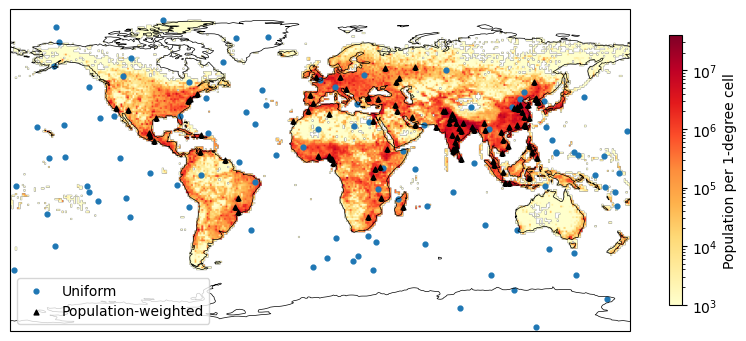

In [4]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()})
image = ax.imshow(
    np.ma.masked_equal(population, 0),
    extent=(bounds[0], bounds[2], bounds[1], bounds[3]),
    origin="upper",
    norm=LogNorm(vmin=1e3, vmax=population.max()),
    cmap="YlOrRd",
    transform=ccrs.PlateCarree(),
)
uniform_points.plot(ax=ax, color="tab:blue", markersize=12, label="Uniform", transform=ccrs.PlateCarree())
population_points.plot(
    ax=ax, color="k", marker="^", markersize=12, label="Population-weighted", transform=ccrs.PlateCarree()
)
ax.coastlines(linewidth=0.5)
ax.set_global()
ax.legend(loc="lower left")
fig.colorbar(image, ax=ax, shrink=0.7, label="Population per 1-degree cell")
plt.show()

For the analyses below, the two sets of points are combined into one GeoDataFrame, labeling each point's distribution.

In [5]:
import pandas as pd

points = pd.concat(
    [
        uniform_points.assign(distribution="Uniform"),
        population_points.assign(distribution="Population-weighted"),
    ],
    ignore_index=True,
)
display(points)

,point_id,geometry,distribution
0,f3c80e0f1149bff0,POINT Z (-98.68701 -1.65778 0),Uniform
1,fcf9476f6d7083d6,POINT Z (-135.16031 -8.9019 0),Uniform
2,f15f44495124c8fa,POINT Z (-76.20093 49.03042 0),Uniform
3,7063758f19160724,POINT Z (31.0043 -55.72766 0),Uniform
4,b1c6ae031fe96035,POINT Z (19.47258 24.63509 0),Uniform
...,...,...,...
195,20569ecc1137aa25,POINT Z (121.14644 28.87734 0),Population-weighted
196,127b0ff3cf763575,POINT Z (-71.49761 42.37583 0),Population-weighted
197,822bcfa2dd9c3d75,POINT Z (105.13609 21.012 0),Population-weighted
198,49f090d081bb7725,POINT Z (53.70945 29.6135 0),Population-weighted


## Imaging Mission

Next, we define a simple imaging mission: one satellite in a sun-synchronous orbit at 705 km altitude with a 10:30 local time descending node (similar to many Earth-observing imagers), carrying a nadir-pointing imager with a 500 km swath. The imager's field of regard is computed from its altitude and swath width. As an optical imager, it requires its targets to be sunlit (`req_target_sunlit=True`).

In [6]:
from datetime import datetime, timedelta, timezone

from tatc import utils
from tatc.schemas import Instrument, Satellite, SunSynchronousOrbit

start = datetime(2026, 6, 1, tzinfo=timezone.utc)
end = start + timedelta(days=1)

imager = Instrument(
    name="Imager",
    field_of_regard=utils.swath_width_to_field_of_regard(705e3, 500e3),
    req_target_sunlit=True,
)
satellite = Satellite(
    name="Imaging Satellite",
    orbit=SunSynchronousOrbit(
        mean_altitude=705e3,
        equator_crossing_time="10:30",
        equator_crossing_ascending=False,
        epoch=start,
    ),
    instruments=[imager],
)
print(f"field of regard: {imager.field_of_regard:.1f} degrees")

field of regard: 38.8 degrees


## Collect Observations

The `collect_observations` function collects the observations of all points during the 1-day simulation (`start` to `end`) together. It accepts shapely points directly, identifying each observed point by the hash of its geometry (`target_hash`), which equals the `point_id` of a generated point. Each observation spans the period (`start` to `end`) when the point lies within the imager's field of regard, with its midpoint as its `epoch`.

In [7]:
from tatc.analysis import collect_observations

observations = collect_observations(list(points.geometry), satellite, start, end)
observations = observations.merge(
    points[["point_id", "distribution"]], left_on="target_hash", right_on="point_id"
).drop(columns="point_id")
display(observations)

,target_hash,geometry,satellite,instrument,start,epoch,end,sat_alt,sat_az,distribution
0,1291f71f2c33fd80,POINT Z (-48.58338 73.61288 0),Imaging Satellite,Imager,2026-06-01 00:20:13.756047041+00:00,2026-06-01 00:20:28.577909829+00:00,2026-06-01 00:20:43.399772617+00:00,70.033296,246.652211,Uniform
1,c4089597e34f07f1,POINT Z (-153.51735 79.75185 0),Imaging Satellite,Imager,2026-06-01 00:25:40.673395937+00:00,2026-06-01 00:26:17.231530364+00:00,2026-06-01 00:26:53.789664791+00:00,86.709829,326.412066,Uniform
2,f2795805433ea1f1,POINT Z (153.25725 40.6861 0),Imaging Satellite,Imager,2026-06-01 00:37:42.277065203+00:00,2026-06-01 00:38:11.811277027+00:00,2026-06-01 00:38:41.345488852+00:00,76.912976,102.518111,Uniform
3,068103bc37d2aa19,POINT Z (147.69208 10.18111 0),Imaging Satellite,Imager,2026-06-01 00:45:56.270027666+00:00,2026-06-01 00:46:32.122853691+00:00,2026-06-01 00:47:07.975679716+00:00,86.523540,282.165559,Uniform
4,76ef601832ef21d7,POINT Z (132.78755 -44.1057 0),Imaging Satellite,Imager,2026-06-01 01:01:04.949555942+00:00,2026-06-01 01:01:38.881016683+00:00,2026-06-01 01:02:12.812477424+00:00,80.825184,105.283218,Uniform
5,c4089597e34f07f1,POINT Z (-153.51735 79.75185 0),Imaging Satellite,Imager,2026-06-01 02:03:39.535536613+00:00,2026-06-01 02:03:58.303688730+00:00,2026-06-01 02:04:17.071840848+00:00,71.161919,350.197184,Uniform
6,ca1a6b44c24a8a6e,POINT Z (129.85251 38.7915 0),Imaging Satellite,Imager,2026-06-01 02:16:48.902805137+00:00,2026-06-01 02:17:25.364539366+00:00,2026-06-01 02:18:01.826273596+00:00,89.230163,284.761857,Uniform
7,75f95cf5744b2b96,POINT Z (121.2684 13.40282 0),Imaging Satellite,Imager,2026-06-01 02:24:17.135620583+00:00,2026-06-01 02:24:34.053787668+00:00,2026-06-01 02:24:50.971954754+00:00,70.697835,101.717750,Population-weighted
8,8619bdfabe2dae4d,POINT Z (123.06917 10.06271 0),Imaging Satellite,Imager,2026-06-01 02:24:45.389206579+00:00,2026-06-01 02:25:20.962807361+00:00,2026-06-01 02:25:56.536408144+00:00,85.558018,282.184218,Population-weighted
9,f6532f422572f4ed,POINT Z (121.21459 -4.26025 0),Imaging Satellite,Imager,2026-06-01 02:28:48.581634569+00:00,2026-06-01 02:29:13.712291046+00:00,2026-06-01 02:29:38.842947524+00:00,74.053422,281.911982,Population-weighted


In one day, the imager observes only some of the points. Points at high latitudes, where the ground tracks of successive orbits converge, are observed more often than points near the equator, and points not sunlit during the satellite's overpasses (for example, in the polar night of the southern winter) are not observed at all.

In [8]:
summary = points.assign(observed=points.point_id.isin(observations.target_hash))
display(summary.groupby("distribution")["observed"].agg(["sum", "count", "mean"]))

,sum,count,mean
distribution,,,
Population-weighted,20,100,0.2
Uniform,30,100,0.3


## Discretize the Ground Track

To identify which points are visible as the satellite moves, the ground track is divided into 1-minute periods. The `collect_ground_track` function projects the imager's field of regard onto the ground at each sample time. Sampling every 10 seconds and dissolving the footprints within each 1-minute period (including those at both its start and end) approximates the area swept by the imager in that period. The `valid_obs` column reports whether the sub-satellite point is sunlit, as required for the imager to observe.

In [9]:
from tatc.analysis import collect_ground_track

period = timedelta(minutes=1)
step = timedelta(seconds=10)
track = collect_ground_track(satellite, pd.date_range(start, end, freq=step))
# assign each footprint to its period, and footprints at a period's end also to that period
track["period"] = (track.time - start) // period
boundary = track[((track.time - start) % period == timedelta(0)) & (track.period > 0)]
track = pd.concat([track, boundary.assign(period=boundary.period - 1)])
track = track[track.period < (end - start) // period]
segments = track.dissolve(by="period", aggfunc={"valid_obs": "any"}).reset_index()
segments.insert(1, "start", start + segments.period * period)
segments.insert(2, "end", segments.start + period)
display(segments)

,period,start,end,geometry,valid_obs
0,0,2026-06-01 00:00:00+00:00,2026-06-01 00:01:00+00:00,"POLYGON Z ((-24.7946 0.01634 0, -24.7946 0.016...",False
1,1,2026-06-01 00:01:00+00:00,2026-06-01 00:02:00+00:00,"POLYGON Z ((-25.56851 3.64336 0, -25.60303 3.9...",False
2,2,2026-06-01 00:02:00+00:00,2026-06-01 00:03:00+00:00,"POLYGON Z ((-26.35629 7.26935 0, -26.39191 7.5...",False
3,3,2026-06-01 00:03:00+00:00,2026-06-01 00:04:00+00:00,"POLYGON Z ((-27.1625 10.89359 0, -27.1995 11.2...",False
4,4,2026-06-01 00:04:00+00:00,2026-06-01 00:05:00+00:00,"POLYGON Z ((-27.99217 14.51528 0, -28.03085 14...",False
...,...,...,...,...,...
1435,1435,2026-06-01 23:55:00+00:00,2026-06-01 23:56:00+00:00,"POLYGON Z ((158.47044 -14.43579 0, 158.16454 -...",True
1436,1436,2026-06-01 23:56:00+00:00,2026-06-01 23:57:00+00:00,"POLYGON Z ((157.7 -18.05979 0, 157.38814 -18.4...",True
1437,1437,2026-06-01 23:57:00+00:00,2026-06-01 23:58:00+00:00,"POLYGON Z ((156.91725 -21.68107 0, 156.59774 -...",True
1438,1438,2026-06-01 23:58:00+00:00,2026-06-01 23:59:00+00:00,"POLYGON Z ((156.11694 -25.29901 0, 155.78786 -...",True


## Identify Visible Points

A point is visible during a period if its observation overlaps that period. Since an observation lasts about one minute for this imager, a point may be visible during two consecutive periods. Counting the visible points (and listing their identifiers) in each period shows when the imager has something to observe.

In [10]:
# periods (by index) overlapped by each observation
first = (observations.start - start) // period
last = np.ceil((observations.end - start) / period).astype(int) - 1
observations["period"] = [list(range(a, b + 1)) for a, b in zip(first, last)]
visible = observations.explode("period").groupby("period").agg(
    points_visible=("target_hash", "count"),
    point_ids=("target_hash", list),
    distributions=("distribution", lambda d: sorted(set(d))),
)
segments = segments.merge(visible, on="period", how="left")
segments["points_visible"] = segments.points_visible.fillna(0).astype(int)
display(segments[segments.points_visible > 0].drop(columns="geometry"))

,period,start,end,valid_obs,points_visible,point_ids,distributions
20,20,2026-06-01 00:20:00+00:00,2026-06-01 00:21:00+00:00,True,1,[1291f71f2c33fd80],[Uniform]
25,25,2026-06-01 00:25:00+00:00,2026-06-01 00:26:00+00:00,True,1,[c4089597e34f07f1],[Uniform]
26,26,2026-06-01 00:26:00+00:00,2026-06-01 00:27:00+00:00,True,1,[c4089597e34f07f1],[Uniform]
37,37,2026-06-01 00:37:00+00:00,2026-06-01 00:38:00+00:00,True,1,[f2795805433ea1f1],[Uniform]
38,38,2026-06-01 00:38:00+00:00,2026-06-01 00:39:00+00:00,True,1,[f2795805433ea1f1],[Uniform]
...,...,...,...,...,...,...,...
1407,1407,2026-06-01 23:27:00+00:00,2026-06-01 23:28:00+00:00,True,1,[0fc3bbcfd1c5626d],[Uniform]
1409,1409,2026-06-01 23:29:00+00:00,2026-06-01 23:30:00+00:00,True,1,[c4089597e34f07f1],[Uniform]
1410,1410,2026-06-01 23:30:00+00:00,2026-06-01 23:31:00+00:00,True,1,[c4089597e34f07f1],[Uniform]
1432,1432,2026-06-01 23:52:00+00:00,2026-06-01 23:53:00+00:00,True,1,[378445c8327bbe9a],[Uniform]


Most 1-minute periods have no visible points: only a small fraction of the imager's time is spent over any of the 200 sample points.

In [11]:
display(segments.points_visible.value_counts().sort_index().rename_axis("points visible").rename("periods"))

points visible
0    1341
1      89
2       8
3       1
4       1
Name: periods, dtype: int64

Finally, the 1-minute ground track segments can be plotted, colored by the number of points visible in each (light gray for none, with hatching where the sub-satellite point is not sunlit), along with the points, outlined in red if observed.

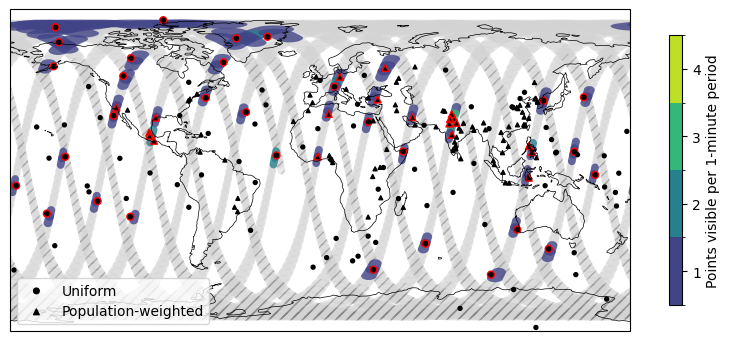

In [12]:
from matplotlib.colors import BoundaryNorm, ListedColormap

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()})
segments[segments.points_visible == 0].plot(
    ax=ax, facecolor="lightgray", edgecolor="none", alpha=0.5, transform=ccrs.PlateCarree()
)
segments[~segments.valid_obs].plot(
    ax=ax, facecolor="none", edgecolor="gray", linewidth=0, hatch="///", alpha=0.3, transform=ccrs.PlateCarree()
)
counts = sorted(segments.points_visible[segments.points_visible > 0].unique())
segments[segments.points_visible > 0].plot(
    ax=ax,
    column="points_visible",
    cmap=ListedColormap(plt.cm.viridis(np.linspace(0.2, 0.9, len(counts)))),
    norm=BoundaryNorm(np.arange(counts[0] - 0.5, counts[-1] + 1), len(counts)),
    edgecolor="none",
    alpha=0.8,
    legend=True,
    legend_kwds={"label": "Points visible per 1-minute period", "shrink": 0.7, "ticks": counts},
    transform=ccrs.PlateCarree(),
)
for distribution, marker in [("Uniform", "o"), ("Population-weighted", "^")]:
    subset = summary[summary.distribution == distribution]
    subset.plot(
        ax=ax,
        marker=marker,
        color="k",
        edgecolor=np.where(subset["observed"], "r", "k"),
        markersize=np.where(subset["observed"], 25, 8),
        label=distribution,
        transform=ccrs.PlateCarree(),
    )
ax.coastlines(linewidth=0.5)
ax.set_global()
ax.legend(loc="lower left")
plt.show()

Zooming in on the period with the most visible points shows its 1-minute ground track segment, the segments just before and after it, and the points visible during it (in red).

,period,start,end,valid_obs,points_visible,point_ids,distributions,label
337,337,2026-06-01 05:37:00+00:00,2026-06-01 05:38:00+00:00,True,3,"[f176bea9fcaa7753, d98e8e423c3c3646, 8bbc6cca8...",[Population-weighted],05:37 to 05:38 UTC
338,338,2026-06-01 05:38:00+00:00,2026-06-01 05:39:00+00:00,True,4,"[d98e8e423c3c3646, 8bbc6cca81e77615, 02828e2d3...",[Population-weighted],05:38 to 05:39 UTC
339,339,2026-06-01 05:39:00+00:00,2026-06-01 05:40:00+00:00,True,2,"[a8e36dbb05858270, b191ebb604774087]",[Population-weighted],05:39 to 05:40 UTC


C:\Users\pgrogan\miniforge3\envs\tatc\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


C:\Users\pgrogan\miniforge3\envs\tatc\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


C:\Users\pgrogan\miniforge3\envs\tatc\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


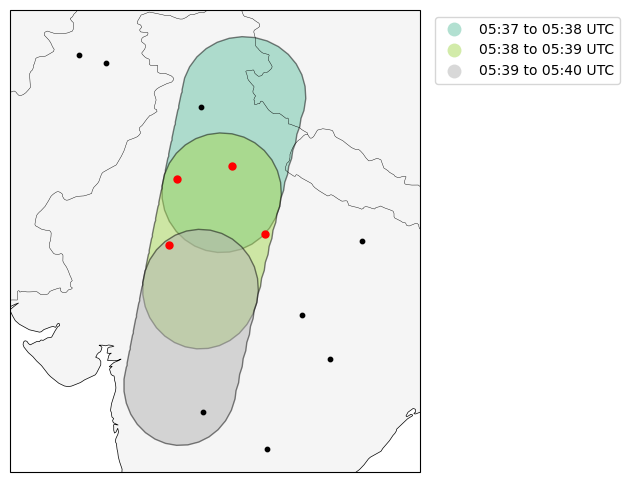

In [13]:
import cartopy.feature as cfeature

busiest = segments.loc[segments.points_visible.idxmax()]
nearby = segments[(segments.period - busiest.period).abs() <= 1].copy()
nearby["label"] = nearby.start.dt.strftime("%H:%M") + " to " + nearby.end.dt.strftime("%H:%M UTC")
display(nearby.drop(columns="geometry"))

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
nearby.plot(
    ax=ax,
    column="label",
    cmap="Set2",
    edgecolor="k",
    alpha=0.5,
    legend=True,
    legend_kwds={"loc": "upper left", "bbox_to_anchor": (1.02, 1)},
    transform=ccrs.PlateCarree(),
)
points.plot(ax=ax, color="k", markersize=10, transform=ccrs.PlateCarree())
points[points.point_id.isin(busiest.point_ids)].plot(
    ax=ax, color="r", markersize=25, transform=ccrs.PlateCarree()
)
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
# a square extent around the segments
west, south, east, north = nearby.total_bounds
half = max(east - west, north - south) / 2 + 1
center = ((west + east) / 2, (south + north) / 2)
ax.set_extent(
    [center[0] - half, center[0] + half, center[1] - half, center[1] + half],
    crs=ccrs.PlateCarree(),
)
plt.show()